In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import re

In [3]:
df = pd.read_csv("J1_tokyo_home_2015-2024.csv")

In [4]:
df["コロナ禍ダミー"] = df["シーズン"].apply(lambda x: 1 if x in [2020, 2021] else 0)

In [5]:
df["国立フラグ"] = df["スタジアム"].str.contains("国立").astype(int)

In [6]:
# 試合日カラムをstr型に変換し､曜日を抽出
df["試合日"] = df["試合日"].astype(str)

df["曜日"] = df["試合日"].str.extract(r"[（(]([^)）]+)[)）]")
# 土日祝に該当するかどうかを判定
df["休日フラグ"] = df["曜日"].str.contains("土|日|祝").astype(int)
df

,シーズン,大会,節,試合日,K/O時刻,ホーム,スコア,アウェイ,スタジアム,入場者数,インターネット中継・TV放送,コロナ禍ダミー,国立フラグ,曜日,休日フラグ
0,2015,Ｊ１ １ｓｔ,第２節第２日,15/03/14(土),14:06,FC東京,0-0,横浜FM,味スタ,30492,スカパー！／スカパー！プレミアムサービス／ＴＢＳ／ＴＯＫＹＯ ＭＸ（録）,0,0,土,1
1,2015,Ｊ１ １ｓｔ,第４節第２日,15/04/04(土),16:03,FC東京,1-0,甲府,味スタ,20743,スカパー！／スカパー！プレミアムサービス,0,0,土,1
2,2015,Ｊ１ １ｓｔ,第６節第２日,15/04/18(土),16:03,FC東京,1-2,広島,味スタ,24369,スカパー！／スカパー！プレミアムサービス／ＴＯＫＹＯ ＭＸ（録）,0,0,土,1
3,2015,Ｊ１ １ｓｔ,第９節第１日,15/05/02(土),16:04,FC東京,2-1,川崎Ｆ,味スタ,42604,スカパー！／スカパー！プレミアムサービス,0,0,土,1
4,2015,Ｊ１ １ｓｔ,第１１節第１日,15/05/10(日),16:04,FC東京,0-1,鹿島,味スタ,42070,スカパー！／スカパー！プレミアムサービス,0,0,日,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,2024,Ｊ１,第２７節第２日,24/08/17(土),19:03,FC東京,0-0,東京Ｖ,味スタ,39921,ＤＡＺＮ／ＴＯＫＹＯ ＭＸ,0,0,土,1
170,2024,Ｊ１,第３０節第２日,24/09/14(土),19:04,FC東京,4-1,名古屋,国立,55896,ＤＡＺＮ,0,1,土,1
171,2024,Ｊ１,第３３節第２日,24/10/05(土),15:03,FC東京,1-1,鳥栖,味スタ,21140,ＤＡＺＮ,0,0,土,1
172,2024,Ｊ１,第３５節第４日,24/11/03(日・祝),14:03,FC東京,0-2,湘南,味スタ,28337,ＤＡＺＮ／テレビ東京（録）,0,0,日・祝,1


### アウェイのみを説明変数としたとき

In [7]:
X = pd.get_dummies(df["アウェイ"],drop_first=True).astype(float)
X = sm.add_constant(X)
y = df["入場者数"].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     1.569
Date:                Mon, 19 Jan 2026   Prob (F-statistic):             0.0463
Time:                        15:21:47   Log-Likelihood:                -1866.0
No. Observations:                 174   AIC:                             3790.
Df Residuals:                     145   BIC:                             3882.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.364e+04   6955.706      4.837      0.0

### アウェイとコロナ禍を説明変数としたとき

In [8]:
# コロナ禍ダミー(2020､2021=1)を追加し､重回帰分析
df["コロナ禍ダミー"] = df["シーズン"].apply(lambda x: 1 if x in [2020, 2021] else 0)
X = pd.get_dummies(df[["アウェイ", "コロナ禍ダミー"]], drop_first=True).astype(float)
X = sm.add_constant(X)
y = df["入場者数"].astype(float)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.636
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                     8.659
Date:                Mon, 19 Jan 2026   Prob (F-statistic):           1.24e-19
Time:                        15:21:47   Log-Likelihood:                -1801.3
No. Observations:                 174   AIC:                             3663.
Df Residuals:                     144   BIC:                             3757.
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.364e+04   4810.000      6.994      0.0

### アウェイ､曜日､コロナ禍を説明変数としたとき

In [9]:
# アウェイ､曜日､コロナ禍ダミーを説明変数とした重回帰分析
X = pd.concat([
    pd.get_dummies(df["アウェイ"], drop_first=True).astype(float) 
    , df[["休日フラグ", "コロナ禍ダミー"]].astype(float)]
    ,axis=1
)
X = sm.add_constant(X)
y = df["入場者数"].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     9.706
Date:                Mon, 19 Jan 2026   Prob (F-statistic):           5.57e-22
Time:                        15:21:47   Log-Likelihood:                -1792.5
No. Observations:                 174   AIC:                             3647.
Df Residuals:                     143   BIC:                             3745.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.652e+04   4938.410      5.369      0.0

### アウェイ､曜日､コロナ禍､国立を説明変数としたとき

In [77]:
# アウェイ､曜日､コロナ禍ダミー､国立フラグを説明変数とした重回帰分析
X = pd.concat([
    pd.get_dummies(df["アウェイ"], drop_first=True).astype(float) 
    , df[["休日フラグ", "コロナ禍ダミー","国立フラグ"]].astype(float)]
    ,axis=1
)
X = sm.add_constant(X)
y = df["入場者数"].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     20.22
Date:                Wed, 21 Jan 2026   Prob (F-statistic):           4.09e-38
Time:                        10:51:58   Log-Likelihood:                -1742.1
No. Observations:                 174   AIC:                             3548.
Df Residuals:                     142   BIC:                             3649.
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.711e+04   3816.610      4.483      0.0

### コロナ禍ダミーのみを説明変数としたとき

In [10]:
# コロナ禍ダミーのみを説明変数とした重回帰分析
X = df[["コロナ禍ダミー"]].astype(float)
X = sm.add_constant(X)
y = df["入場者数"].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.472
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     153.9
Date:                Mon, 19 Jan 2026   Prob (F-statistic):           1.19e-25
Time:                        15:21:47   Log-Likelihood:                -1833.5
No. Observations:                 174   AIC:                             3671.
Df Residuals:                     172   BIC:                             3677.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.786e+04    780.878     35.674      0.0

In [14]:
df["試合日"].unique()[:10]

array(['15/03/14(土)', '15/04/04(土)', '15/04/18(土)', '15/05/02(土)',
       '15/05/10(日)', '15/05/23(土)', '15/05/30(土)', '15/06/27(土)',
       '15/07/15(水)', '15/07/19(日)'], dtype=object)

In [68]:
# 試合日から日付部分を抽出
df["date_str"] = df["試合日"].str.extract(r"(\d{2}/\d{2}/\d{2})")[0]

# K/O時刻を文字列に変換（null値対策）
df["K/O時刻"] = df["K/O時刻"].astype(str)

# 日付とK/O時刻を組み合わせてdatetime型に変換
df["datetime"] = pd.to_datetime(df["date_str"] + " " + df["K/O時刻"], format="%y/%m/%d %H:%M", errors="coerce")

# 日付のみのカラムも保持
df["date"] = pd.to_datetime(df["date_str"], format="%y/%m/%d", errors="coerce")

# datetimeから年を抽出
df["year"] = df["datetime"].dt.year

# datetimeから時間を抽出（14:00なら14）
df["hour"] = df["datetime"].dt.hour

# 一時カラムを削除
df.drop(columns=["date_str"], inplace=True)

In [16]:
df_weather = pd.read_csv("data.csv", header=4)
df_weather

,Unnamed: 0,Unnamed: 1,品質情報,均質番号,Unnamed: 4,現象なし情報,品質情報.1,均質番号.1
0,2015/1/1,8.2,8,1,0.0,0,8,1
1,2015/1/2,7.9,8,1,0.0,1,8,1
2,2015/1/3,8.9,8,1,0.0,1,8,1
3,2015/1/4,9.3,8,1,0.0,1,8,1
4,2015/1/5,12.9,8,1,0.0,1,8,1
...,...,...,...,...,...,...,...,...
3648,2024/12/27,12.7,8,1,0.0,1,8,1
3649,2024/12/28,11.5,8,1,0.0,0,8,1
3650,2024/12/29,12.3,8,1,0.0,1,8,1
3651,2024/12/30,10.3,8,1,0.0,1,8,1


In [17]:
# df_weatherの0列目､1列目､4列目を抽出し､列目をdate, temperature,rainに変更
df_weather = df_weather.iloc[:, [0, 1, 4]]
df_weather.columns = ["date", "temperature", "rain"]
df_weather

,date,temperature,rain
0,2015/1/1,8.2,0.0
1,2015/1/2,7.9,0.0
2,2015/1/3,8.9,0.0
3,2015/1/4,9.3,0.0
4,2015/1/5,12.9,0.0
...,...,...,...
3648,2024/12/27,12.7,0.0
3649,2024/12/28,11.5,0.0
3650,2024/12/29,12.3,0.0
3651,2024/12/30,10.3,0.0


In [18]:
# df_weatherのdateをdatetime型に変換
df_weather["date"] = pd.to_datetime(df_weather["date"], format="%Y/%m/%d")
df_weather

/var/folders/5s/tm2tnv153l5gfqlv4g_q9dqw0000gn/T/ipykernel_12158/2688324877.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_weather["date"] = pd.to_datetime(df_weather["date"], format="%Y/%m/%d")


,date,temperature,rain
0,2015-01-01,8.2,0.0
1,2015-01-02,7.9,0.0
2,2015-01-03,8.9,0.0
3,2015-01-04,9.3,0.0
4,2015-01-05,12.9,0.0
...,...,...,...
3648,2024-12-27,12.7,0.0
3649,2024-12-28,11.5,0.0
3650,2024-12-29,12.3,0.0
3651,2024-12-30,10.3,0.0


In [19]:
df

,シーズン,大会,節,試合日,K/O時刻,ホーム,スコア,アウェイ,スタジアム,入場者数,インターネット中継・TV放送,コロナ禍ダミー,国立フラグ,曜日,休日フラグ,date
0,2015,Ｊ１ １ｓｔ,第２節第２日,15/03/14(土),14:06,FC東京,0-0,横浜FM,味スタ,30492,スカパー！／スカパー！プレミアムサービス／ＴＢＳ／ＴＯＫＹＯ ＭＸ（録）,0,0,土,1,2015-03-14
1,2015,Ｊ１ １ｓｔ,第４節第２日,15/04/04(土),16:03,FC東京,1-0,甲府,味スタ,20743,スカパー！／スカパー！プレミアムサービス,0,0,土,1,2015-04-04
2,2015,Ｊ１ １ｓｔ,第６節第２日,15/04/18(土),16:03,FC東京,1-2,広島,味スタ,24369,スカパー！／スカパー！プレミアムサービス／ＴＯＫＹＯ ＭＸ（録）,0,0,土,1,2015-04-18
3,2015,Ｊ１ １ｓｔ,第９節第１日,15/05/02(土),16:04,FC東京,2-1,川崎Ｆ,味スタ,42604,スカパー！／スカパー！プレミアムサービス,0,0,土,1,2015-05-02
4,2015,Ｊ１ １ｓｔ,第１１節第１日,15/05/10(日),16:04,FC東京,0-1,鹿島,味スタ,42070,スカパー！／スカパー！プレミアムサービス,0,0,日,1,2015-05-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,2024,Ｊ１,第２７節第２日,24/08/17(土),19:03,FC東京,0-0,東京Ｖ,味スタ,39921,ＤＡＺＮ／ＴＯＫＹＯ ＭＸ,0,0,土,1,2024-08-17
170,2024,Ｊ１,第３０節第２日,24/09/14(土),19:04,FC東京,4-1,名古屋,国立,55896,ＤＡＺＮ,0,1,土,1,2024-09-14
171,2024,Ｊ１,第３３節第２日,24/10/05(土),15:03,FC東京,1-1,鳥栖,味スタ,21140,ＤＡＺＮ,0,0,土,1,2024-10-05
172,2024,Ｊ１,第３５節第４日,24/11/03(日・祝),14:03,FC東京,0-2,湘南,味スタ,28337,ＤＡＺＮ／テレビ東京（録）,0,0,日・祝,1,2024-11-03


In [75]:
# 読み込み
df = pd.read_csv("J1_tokyo_home_2015-2024.csv")
# 各変数
df["コロナ禍ダミー"] = df["シーズン"].apply(lambda x: 1 if x in [2020, 2021] else 0)
df["国立フラグ"] = df["スタジアム"].str.contains("国立").astype(int)
df["試合日"] = df["試合日"].astype(str)
df["曜日"] = df["試合日"].str.extract(r"[（(]([^)）]+)[)）]")
df["休日フラグ"] = df["曜日"].str.contains("土|日|祝").astype(int)
df["rolling_mean_3"] = df["入場者数"].rolling(window=3).mean()

# 試合日から日付部分を抽出し、K/O時刻と組み合わせてdatetime型に変換
df["date_str"] = df["試合日"].str.extract(r"(\d{2}/\d{2}/\d{2})")[0]
df["K/O時刻"] = df["K/O時刻"].astype(str)
df["datetime"] = pd.to_datetime(df["date_str"] + " " + df["K/O時刻"], format="%y/%m/%d %H:%M", errors="coerce")
df["date"] = pd.to_datetime(df["date_str"], format="%y/%m/%d", errors="coerce")
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["hour"] = df["datetime"].dt.hour
df.drop(columns=["date_str"], inplace=True)



# dateをキーにしてdfのマージ
df_merged = pd.merge(df, df_weather, on="date", how="left")
df_merged.head()

,シーズン,大会,節,試合日,K/O時刻,ホーム,スコア,アウェイ,スタジアム,入場者数,...,曜日,休日フラグ,rolling_mean_3,datetime,date,year,month,hour,temperature,rain
0,2015,Ｊ１ １ｓｔ,第２節第２日,15/03/14(土),14:06,FC東京,0-0,横浜FM,味スタ,30492,...,土,1,NaN,2015-03-14 14:06:00,2015-03-14,2015,3,14,13.5,0.0
1,2015,Ｊ１ １ｓｔ,第４節第２日,15/04/04(土),16:03,FC東京,1-0,甲府,味スタ,20743,...,土,1,NaN,2015-04-04 16:03:00,2015-04-04,2015,4,16,19.1,0.0
2,2015,Ｊ１ １ｓｔ,第６節第２日,15/04/18(土),16:03,FC東京,1-2,広島,味スタ,24369,...,土,1,25201.333333,2015-04-18 16:03:00,2015-04-18,2015,4,16,19.7,0.0
3,2015,Ｊ１ １ｓｔ,第９節第１日,15/05/02(土),16:04,FC東京,2-1,川崎Ｆ,味スタ,42604,...,土,1,29238.666667,2015-05-02 16:04:00,2015-05-02,2015,5,16,27.6,0.0
4,2015,Ｊ１ １ｓｔ,第１１節第１日,15/05/10(日),16:04,FC東京,0-1,鹿島,味スタ,42070,...,日,1,36347.666667,2015-05-10 16:04:00,2015-05-10,2015,5,16,27.0,0.0


### 気温プラス雨が降ったか否か

In [81]:
df_merged["temp_zone"] = pd.cut(df_merged["temperature"], bins=[0,10,15,20,25,30,35,40],
                         labels=["寒い","やや寒い","快適","快適2","暑い","猛暑","酷暑"])

df_merged["rain_flag"] = df_merged["rain"].apply(lambda x: 1 if x > 0 else 0)

In [82]:
# アウェイ､曜日､コロナ禍ダミー､気温､雨
X = pd.concat([
    pd.get_dummies(df_merged["アウェイ"], drop_first=True).astype(float) 
    ,pd.get_dummies(df_merged["temp_zone"], drop_first=True).astype(float)
    ,df_merged[["休日フラグ", "コロナ禍ダミー","国立フラグ","rain_flag"]].astype(float)]
    ,axis=1
)
X = sm.add_constant(X)
y = df["入場者数"].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     17.65
Date:                Wed, 21 Jan 2026   Prob (F-statistic):           2.27e-36
Time:                        11:35:51   Log-Likelihood:                -1733.7
No. Observations:                 174   AIC:                             3545.
Df Residuals:                     135   BIC:                             3669.
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.348e+04   5276.010      2.554      0.0

In [93]:
df_merged["lag1"] = df_merged["入場者数"].shift(1)
df_merged["lag2"] = df_merged["入場者数"].shift(2)
df_merged["rolling_mean_2"] = df_merged["入場者数"].rolling(window=2).mean()
df_merged["rolling_mean_5"] = df_merged["入場者数"].rolling(window=5).mean()
df_merged["rolling_mean_3"] = df_merged["入場者数"].rolling(window=3).mean()
df_merged["rolling_mean_7"] = df_merged["入場者数"].rolling(window=7).mean()

In [48]:
df_merged.head()

,シーズン,大会,節,試合日,K/O時刻,ホーム,スコア,アウェイ,スタジアム,入場者数,...,temperature,rain,rain_flag,temp2,temp_zone,lag1,lag2,rolling_mean_5,rolling_mean_3,rolling_mean_7
0,2015,Ｊ１ １ｓｔ,第２節第２日,15/03/14(土),14:06,FC東京,0-0,横浜FM,味スタ,30492,...,13.5,0.0,0,182.25,やや寒い,NaN,NaN,NaN,NaN,NaN
1,2015,Ｊ１ １ｓｔ,第４節第２日,15/04/04(土),16:03,FC東京,1-0,甲府,味スタ,20743,...,19.1,0.0,0,364.81,快適,30492.0,NaN,NaN,NaN,NaN
2,2015,Ｊ１ １ｓｔ,第６節第２日,15/04/18(土),16:03,FC東京,1-2,広島,味スタ,24369,...,19.7,0.0,0,388.09,快適,20743.0,30492.0,NaN,25201.333333,NaN
3,2015,Ｊ１ １ｓｔ,第９節第１日,15/05/02(土),16:04,FC東京,2-1,川崎Ｆ,味スタ,42604,...,27.6,0.0,0,761.76,暑い,24369.0,20743.0,NaN,29238.666667,NaN
4,2015,Ｊ１ １ｓｔ,第１１節第１日,15/05/10(日),16:04,FC東京,0-1,鹿島,味スタ,42070,...,27.0,0.0,0,729.00,暑い,42604.0,24369.0,32055.6,36347.666667,NaN


### 前試合に勝ったか否か

In [97]:
df_merged

,シーズン,大会,節,試合日,K/O時刻,ホーム,スコア,アウェイ,スタジアム,入場者数,...,hour,temperature,rain,temp_zone,rain_flag,lag1,lag2,rolling_mean_5,rolling_mean_7,rolling_mean_2
0,2015,Ｊ１ １ｓｔ,第２節第２日,15/03/14(土),14:06,FC東京,0-0,横浜FM,味スタ,30492,...,14,13.5,0.0,やや寒い,0,NaN,NaN,NaN,NaN,NaN
1,2015,Ｊ１ １ｓｔ,第４節第２日,15/04/04(土),16:03,FC東京,1-0,甲府,味スタ,20743,...,16,19.1,0.0,快適,0,30492.0,NaN,NaN,NaN,25617.5
2,2015,Ｊ１ １ｓｔ,第６節第２日,15/04/18(土),16:03,FC東京,1-2,広島,味スタ,24369,...,16,19.7,0.0,快適,0,20743.0,30492.0,NaN,NaN,22556.0
3,2015,Ｊ１ １ｓｔ,第９節第１日,15/05/02(土),16:04,FC東京,2-1,川崎Ｆ,味スタ,42604,...,16,27.6,0.0,暑い,0,24369.0,20743.0,NaN,NaN,33486.5
4,2015,Ｊ１ １ｓｔ,第１１節第１日,15/05/10(日),16:04,FC東京,0-1,鹿島,味スタ,42070,...,16,27.0,0.0,暑い,0,42604.0,24369.0,32055.6,NaN,42337.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,2024,Ｊ１,第２７節第２日,24/08/17(土),19:03,FC東京,0-0,東京Ｖ,味スタ,39921,...,19,35.9,0.0,酷暑,0,37452.0,57885.0,34243.8,31967.285714,38686.5
170,2024,Ｊ１,第３０節第２日,24/09/14(土),19:04,FC東京,4-1,名古屋,国立,55896,...,19,34.5,0.0,猛暑,0,39921.0,37452.0,42257.4,35956.428571,47908.5
171,2024,Ｊ１,第３３節第２日,24/10/05(土),15:03,FC東京,1-1,鳥栖,味スタ,21140,...,15,24.5,9.5,快適2,1,55896.0,39921.0,42458.8,35465.000000,38518.0
172,2024,Ｊ１,第３５節第４日,24/11/03(日・祝),14:03,FC東京,0-2,湘南,味スタ,28337,...,14,22.6,0.0,快適2,0,21140.0,55896.0,36549.2,37252.000000,24738.5


In [98]:
df_merged[["home_score", "away_score"]] = df_merged["スコア"].str.split("-", expand=True).astype(int)

In [103]:
#  勝った場合が1､負けと引き分けが0
df_merged["result_numeric"] = np.select(
    [
        df_merged["home_score"] > df_merged["away_score"],
        df_merged["home_score"] == df_merged["away_score"],
        df_merged["home_score"] < df_merged["away_score"]
    ],
    [1, 0, 0],
    default=0
)


In [104]:
# 前の試合､勝ったか否かのフラグ
df_merged["lag1_result_numeric"] = df_merged["result_numeric"].shift(1)
df_merged.head()


,シーズン,大会,節,試合日,K/O時刻,ホーム,スコア,アウェイ,スタジアム,入場者数,...,rain_flag,lag1,lag2,rolling_mean_5,rolling_mean_7,rolling_mean_2,home_score,away_score,result_numeric,lag1_result_numeric
0,2015,Ｊ１ １ｓｔ,第２節第２日,15/03/14(土),14:06,FC東京,0-0,横浜FM,味スタ,30492,...,0,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
1,2015,Ｊ１ １ｓｔ,第４節第２日,15/04/04(土),16:03,FC東京,1-0,甲府,味スタ,20743,...,0,30492.0,NaN,NaN,NaN,25617.5,1,0,1,0.0
2,2015,Ｊ１ １ｓｔ,第６節第２日,15/04/18(土),16:03,FC東京,1-2,広島,味スタ,24369,...,0,20743.0,30492.0,NaN,NaN,22556.0,1,2,0,1.0
3,2015,Ｊ１ １ｓｔ,第９節第１日,15/05/02(土),16:04,FC東京,2-1,川崎Ｆ,味スタ,42604,...,0,24369.0,20743.0,NaN,NaN,33486.5,2,1,1,0.0
4,2015,Ｊ１ １ｓｔ,第１１節第１日,15/05/10(日),16:04,FC東京,0-1,鹿島,味スタ,42070,...,0,42604.0,24369.0,32055.6,NaN,42337.0,0,1,0,1.0


In [106]:
X = pd.concat([
    pd.get_dummies(df_merged["アウェイ"], drop_first=True).astype(float),
    df_merged[["コロナ禍ダミー","国立フラグ","休日フラグ","lag1_result_numeric"]].astype(float)
], axis=1).dropna()
X = sm.add_constant(X)
y = df_merged.loc[X.index,"入場者数"].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     19.36
Date:                Mon, 26 Jan 2026   Prob (F-statistic):           3.51e-37
Time:                        11:37:27   Log-Likelihood:                -1732.3
No. Observations:                 173   AIC:                             3531.
Df Residuals:                     140   BIC:                             3635.
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.709e+04   3

### rolling_mean, lag系

In [118]:
X = pd.concat([
    pd.get_dummies(df_merged["アウェイ"], drop_first=True).astype(float),
    df_merged[["コロナ禍ダミー","国立フラグ","休日フラグ","lag1","rain_flag"]].astype(float)
], axis=1).dropna()
X = sm.add_constant(X)
y = df_merged.loc[X.index,"入場者数"].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     19.58
Date:                Mon, 26 Jan 2026   Prob (F-statistic):           1.06e-37
Time:                        14:13:02   Log-Likelihood:                -1728.8
No. Observations:                 173   AIC:                             3526.
Df Residuals:                     139   BIC:                             3633.
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.539e+04   4119.356      3.735      0.0

In [119]:
X = pd.concat([
    pd.get_dummies(df_merged["アウェイ"], drop_first=True).astype(float),
    df_merged[["コロナ禍ダミー","国立フラグ","休日フラグ","rolling_mean_2","rain_flag"]].astype(float)
], axis=1).dropna()
X = sm.add_constant(X)
y = df_merged.loc[X.index,"入場者数"].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     31.77
Date:                Mon, 26 Jan 2026   Prob (F-statistic):           1.03e-49
Time:                        14:38:45   Log-Likelihood:                -1693.0
No. Observations:                 173   AIC:                             3454.
Df Residuals:                     139   BIC:                             3561.
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           2878.4390   3505.559      0.

In [116]:
X = pd.concat([
    pd.get_dummies(df_merged["アウェイ"], drop_first=True).astype(float),
    df_merged[["コロナ禍ダミー","国立フラグ","休日フラグ","rolling_mean_3","rain_flag"]].astype(float)
], axis=1).dropna()
X = sm.add_constant(X)
y = df_merged.loc[X.index,"入場者数"].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     25.55
Date:                Mon, 26 Jan 2026   Prob (F-statistic):           5.61e-44
Time:                        14:12:11   Log-Likelihood:                -1699.5
No. Observations:                 172   AIC:                             3467.
Df Residuals:                     138   BIC:                             3574.
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3837.7781   4034.956      0.

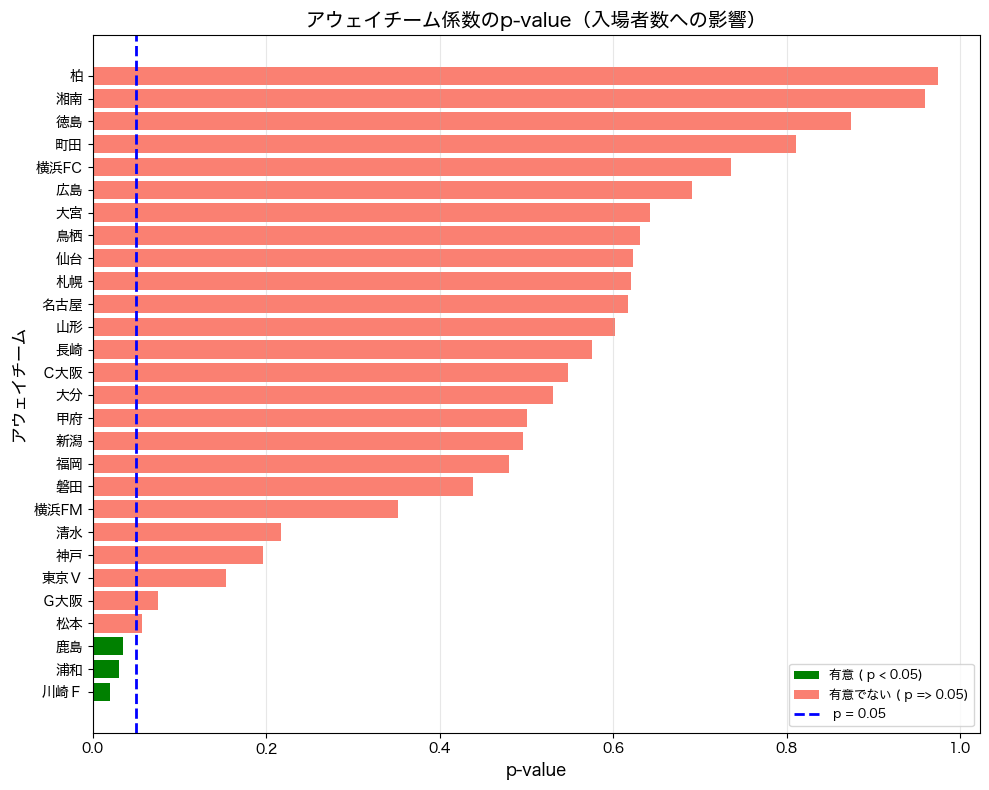


【有意】p < 0.05 のアウェイチーム:
  川崎Ｆ: p-value = 0.0200, 係数 = +7578.2
  浦和: p-value = 0.0298, 係数 = +7014.9
  鹿島: p-value = 0.0348, 係数 = +6832.1


In [129]:
# アウェイチームの係数のp-valueの図示
# モデルのp-valueを取得
plt.rcParams['font.family'] = 'Hiragino Sans'

pvalues = model.pvalues

# アウェイチーム（チーム名）のみを抽出（const、コロナ禍ダミー等を除外）
exclude_vars = ['const', 'コロナ禍ダミー', '国立フラグ', '休日フラグ', 'rolling_mean_3', 'rolling_mean_5', 'rain_flag',"rolling_mean_2"]
team_pvalues = pvalues.drop(labels=[v for v in exclude_vars if v in pvalues.index], errors='ignore')

# p-valueでソート（小さい順）
team_pvalues_sorted = team_pvalues.sort_values()

# 可視化
fig, ax = plt.subplots(figsize=(10, 8))

# カラーマップ：p < 0.05 は緑、0.05 ≤ p < 0.10 は黄色、それ以外は赤
def get_color(p):
    if p < 0.05:
        return 'green'
    else:
        return 'salmon'

colors = [get_color(p) for p in team_pvalues_sorted.values]

# 横棒グラフで表示
bars = ax.barh(range(len(team_pvalues_sorted)), team_pvalues_sorted.values, color=colors)

# y軸のラベルをチーム名に
ax.set_yticks(range(len(team_pvalues_sorted)))
ax.set_yticklabels(team_pvalues_sorted.index)

# p = 0.05の基準線
ax.axvline(x=0.05, color='blue', linestyle='--', linewidth=2, label=' p = 0.05 ')

# 凡例用のダミー（色の説明）
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label='有意 ( p < 0.05)'),
    Patch(facecolor='salmon', label='有意でない ( p => 0.05)'),
    plt.Line2D([0], [0], color='blue', linestyle='--', linewidth=2, label=' p = 0.05 ')
]

# ラベルとタイトル
ax.set_xlabel('p-value', fontsize=12)
ax.set_ylabel('アウェイチーム', fontsize=12)
ax.set_title('アウェイチーム係数のp-value（入場者数への影響）', fontsize=14)
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

# グリッド追加
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 統計的に有意なチーム（p < 0.05）を表示
print("\n【有意】p < 0.05 のアウェイチーム:")
significant_teams = team_pvalues[team_pvalues < 0.05].sort_values()
for team, p in significant_teams.items():
    coef = model.params[team]
    print(f"  {team}: p-value = {p:.4f}, 係数 = {coef:+.1f}")


In [117]:
X = pd.concat([
    pd.get_dummies(df_merged["アウェイ"], drop_first=True).astype(float),
    df_merged[["コロナ禍ダミー","国立フラグ","休日フラグ","rolling_mean_5","rain_flag"]].astype(float)
], axis=1).dropna()
X = sm.add_constant(X)
y = df_merged.loc[X.index,"入場者数"].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     23.29
Date:                Mon, 26 Jan 2026   Prob (F-statistic):           2.55e-41
Time:                        14:12:25   Log-Likelihood:                -1685.2
No. Observations:                 170   AIC:                             3438.
Df Residuals:                     136   BIC:                             3545.
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           5260.6237   4208.112      1.

### 説明変数全部込み

In [113]:
X = pd.concat([
    pd.get_dummies(df_merged["アウェイ"], drop_first=True).astype(float),
    df_merged[["コロナ禍ダミー","国立フラグ","休日フラグ","rolling_mean_3","rain_flag"]].astype(float)
], axis=1).dropna()
X = sm.add_constant(X)
y = df.loc[X.index,"入場者数"].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     25.55
Date:                Mon, 26 Jan 2026   Prob (F-statistic):           5.61e-44
Time:                        13:37:05   Log-Likelihood:                -1699.5
No. Observations:                 172   AIC:                             3467.
Df Residuals:                     138   BIC:                             3574.
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3837.7781   4034.956      0.

In [112]:
df_merged.to_csv("to_ML.csv",index=False)

### 日付系(year, month, hour)

In [76]:
# 説明変数
X = pd.concat([
    pd.get_dummies(df["アウェイ"], drop_first=True).astype(float),
    df[["コロナ禍ダミー","国立フラグ","休日フラグ","rolling_mean_3","year","month","hour"]],
], axis=1).dropna()
X = sm.add_constant(X)

# 目的変数
y = df.loc[X.index,"入場者数"].astype(float)


# モデル
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     24.33
Date:                Wed, 21 Jan 2026   Prob (F-statistic):           3.68e-43
Time:                        10:42:13   Log-Likelihood:                -1697.7
No. Observations:                 172   AIC:                             3467.
Df Residuals:                     136   BIC:                             3581.
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           5.666e+05   3.38e+05      1.

In [56]:
df_merged

,シーズン,大会,節,試合日,K/O時刻,ホーム,スコア,アウェイ,スタジアム,入場者数,インターネット中継・TV放送,コロナ禍ダミー,国立フラグ,曜日,休日フラグ,datetime,date,temperature,rain
0,2015,Ｊ１ １ｓｔ,第２節第２日,15/03/14(土),14:06,FC東京,0-0,横浜FM,味スタ,30492,スカパー！／スカパー！プレミアムサービス／ＴＢＳ／ＴＯＫＹＯ ＭＸ（録）,0,0,土,1,2015-03-14 14:06:00,2015-03-14,13.5,0.0
1,2015,Ｊ１ １ｓｔ,第４節第２日,15/04/04(土),16:03,FC東京,1-0,甲府,味スタ,20743,スカパー！／スカパー！プレミアムサービス,0,0,土,1,2015-04-04 16:03:00,2015-04-04,19.1,0.0
2,2015,Ｊ１ １ｓｔ,第６節第２日,15/04/18(土),16:03,FC東京,1-2,広島,味スタ,24369,スカパー！／スカパー！プレミアムサービス／ＴＯＫＹＯ ＭＸ（録）,0,0,土,1,2015-04-18 16:03:00,2015-04-18,19.7,0.0
3,2015,Ｊ１ １ｓｔ,第９節第１日,15/05/02(土),16:04,FC東京,2-1,川崎Ｆ,味スタ,42604,スカパー！／スカパー！プレミアムサービス,0,0,土,1,2015-05-02 16:04:00,2015-05-02,27.6,0.0
4,2015,Ｊ１ １ｓｔ,第１１節第１日,15/05/10(日),16:04,FC東京,0-1,鹿島,味スタ,42070,スカパー！／スカパー！プレミアムサービス,0,0,日,1,2015-05-10 16:04:00,2015-05-10,27.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,2024,Ｊ１,第２７節第２日,24/08/17(土),19:03,FC東京,0-0,東京Ｖ,味スタ,39921,ＤＡＺＮ／ＴＯＫＹＯ ＭＸ,0,0,土,1,2024-08-17 19:03:00,2024-08-17,35.9,0.0
170,2024,Ｊ１,第３０節第２日,24/09/14(土),19:04,FC東京,4-1,名古屋,国立,55896,ＤＡＺＮ,0,1,土,1,2024-09-14 19:04:00,2024-09-14,34.5,0.0
171,2024,Ｊ１,第３３節第２日,24/10/05(土),15:03,FC東京,1-1,鳥栖,味スタ,21140,ＤＡＺＮ,0,0,土,1,2024-10-05 15:03:00,2024-10-05,24.5,9.5
172,2024,Ｊ１,第３５節第４日,24/11/03(日・祝),14:03,FC東京,0-2,湘南,味スタ,28337,ＤＡＺＮ／テレビ東京（録）,0,0,日・祝,1,2024-11-03 14:03:00,2024-11-03,22.6,0.0
